In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
from sklearn.datasets import load_iris

In [40]:
iris = load_iris()

In [41]:
data = iris["data"]
target = iris["target"]

In [42]:
df = pd.DataFrame(data, columns=iris["feature_names"])

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, target, random_state=42, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [51]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

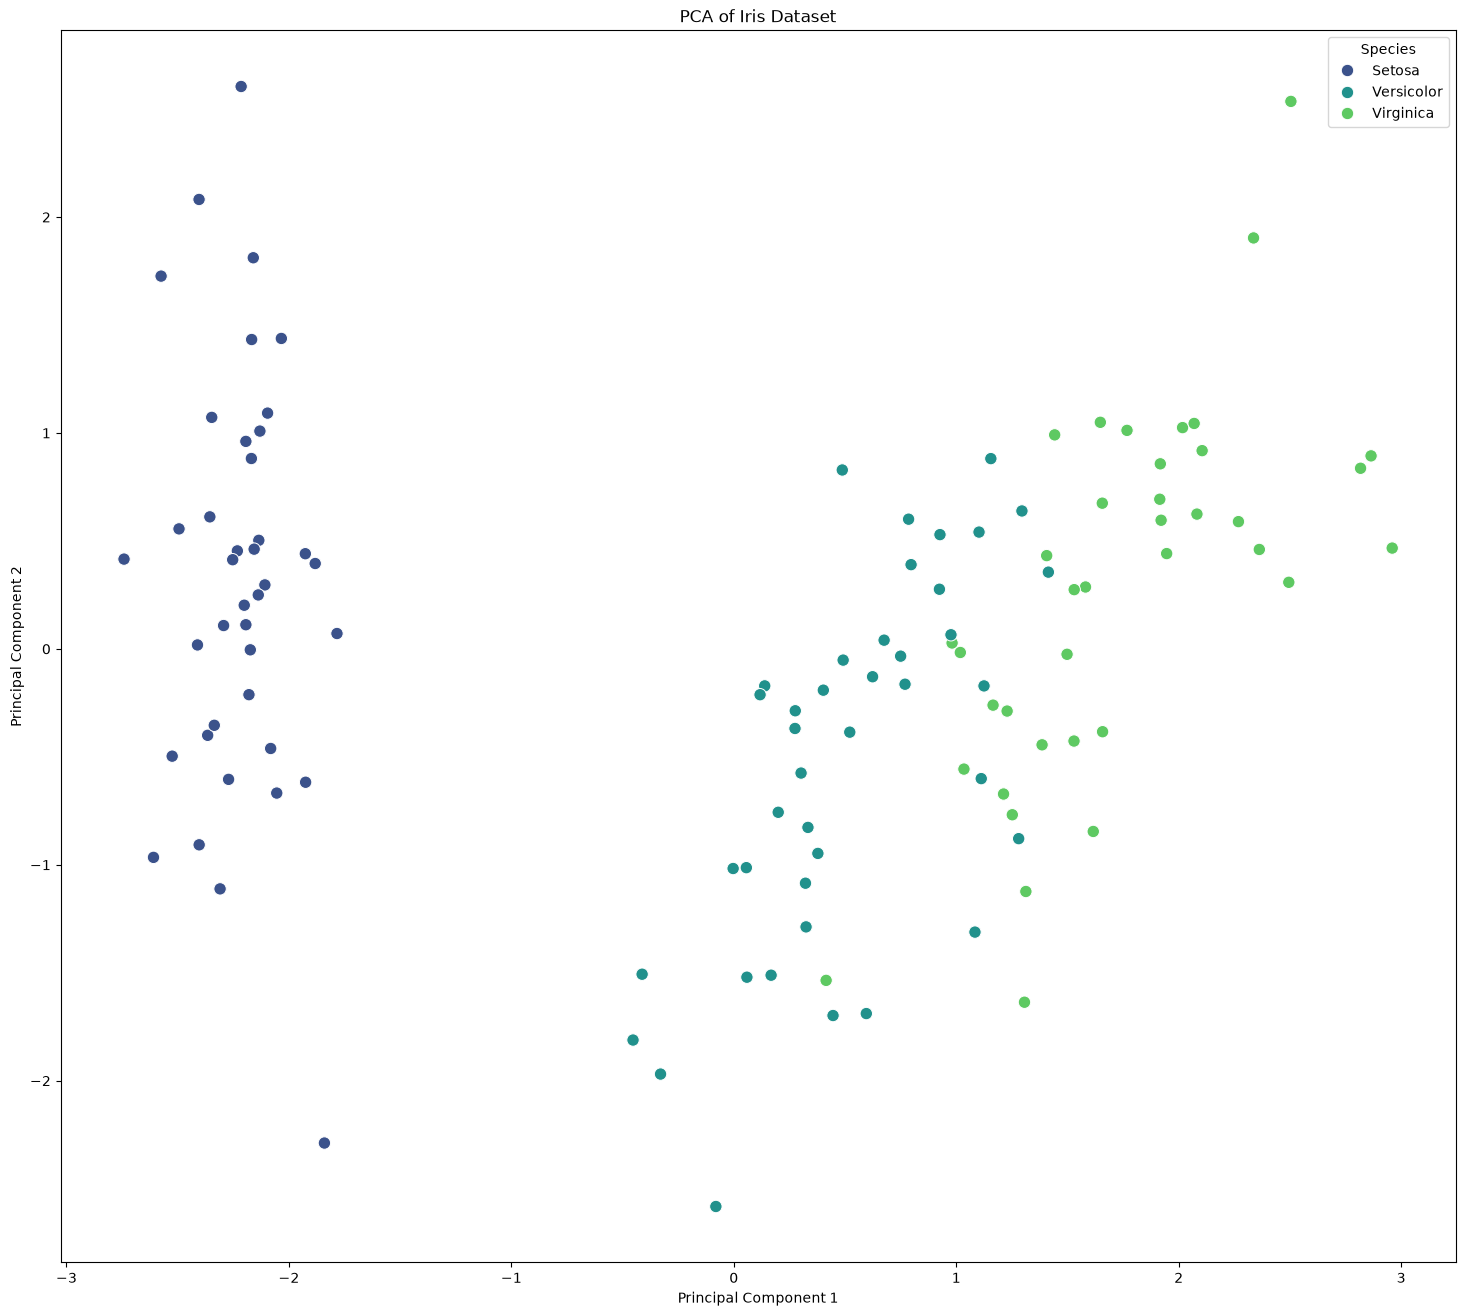

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pca_df = pd.DataFrame({
    "PC1": X_train[:, 0],
    "PC2": X_train[:, 1],
    "Species": y_train
})

pca_df["Species"] = pca_df["Species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

plt.figure(figsize=(18, 16))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Species",
    palette="viridis",
    s=80
)

plt.title("PCA of Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Species")
plt.show()

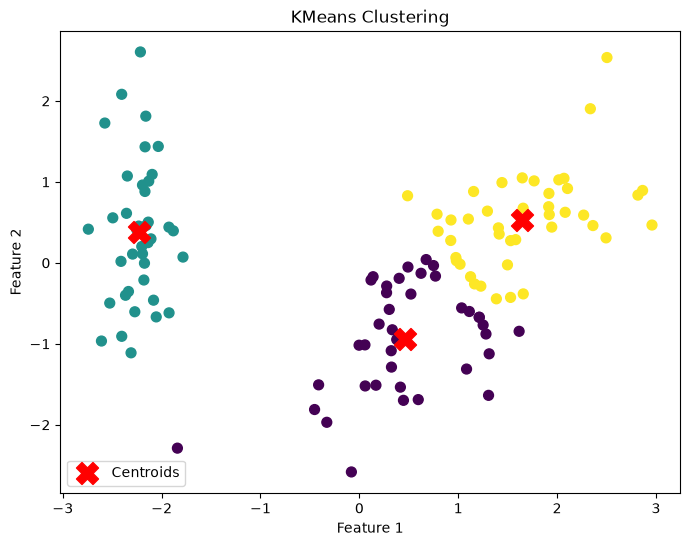

In [56]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
y_pred = kmeans.fit_predict(X_train)
plt.figure(figsize=(8,6))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_pred,
    cmap="viridis",
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KMeans Clustering")
plt.show()


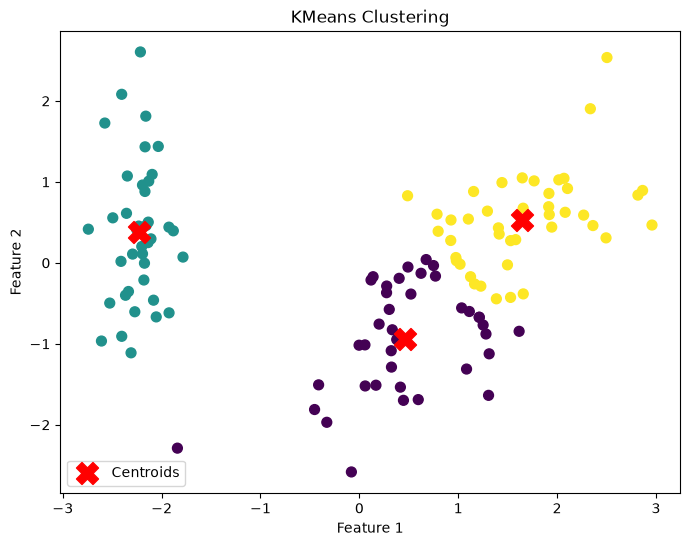

In [63]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
y_pred = kmeans.fit_predict(X_train)
plt.figure(figsize=(8,6))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_pred,
    cmap="viridis",
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KMeans Clustering")
plt.show()

Optimal number of clusters: 3


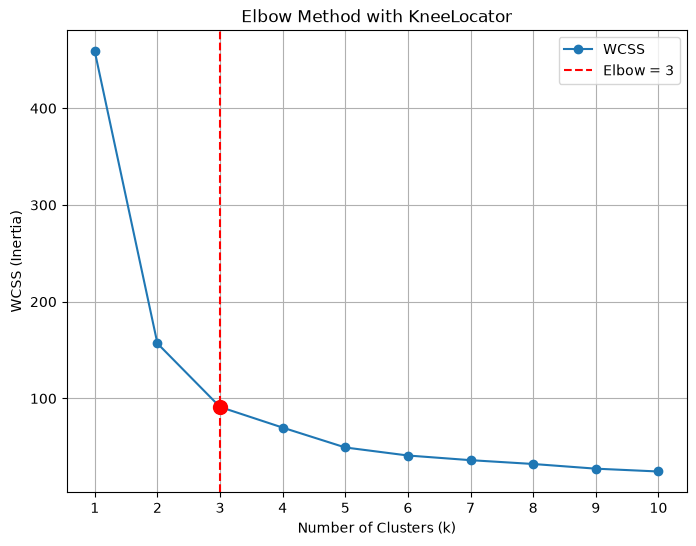

In [67]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt

wcss = []

# Compute WCSS for different values of k
K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

# Find the elbow
knee = KneeLocator(
    K,
    wcss,
    curve="convex",
    direction="decreasing"
)

print("Optimal number of clusters:", knee.elbow)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(K, wcss, marker="o", label="WCSS")

# Mark the elbow point
plt.axvline(
    x=knee.elbow,
    color="red",
    linestyle="--",
    label=f"Elbow = {knee.elbow}"
)

plt.scatter(
    knee.elbow,
    knee.elbow_y,
    color="red",
    s=100,
    zorder=5
)

plt.title("Elbow Method with KneeLocator")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(K)
plt.grid(True)
plt.legend()

plt.show()

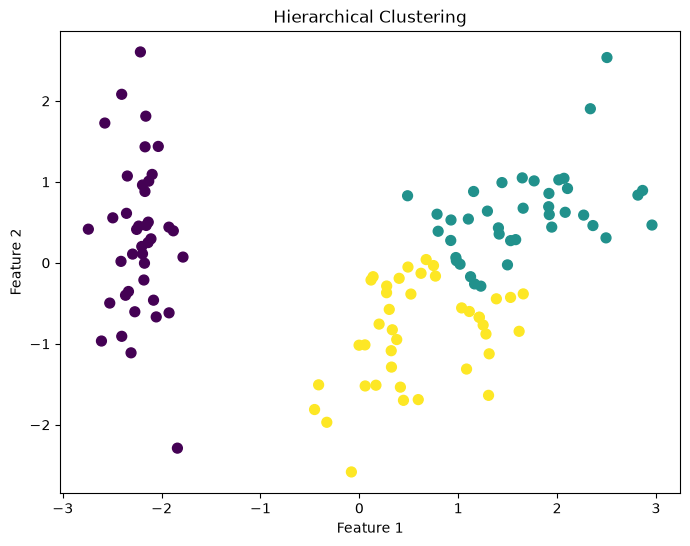

In [68]:
#Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
y_pred = hc.fit_predict(X_train)
plt.figure(figsize=(8,6))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_pred,
    cmap="viridis",
    s=50
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Hierarchical Clustering")
plt.show()

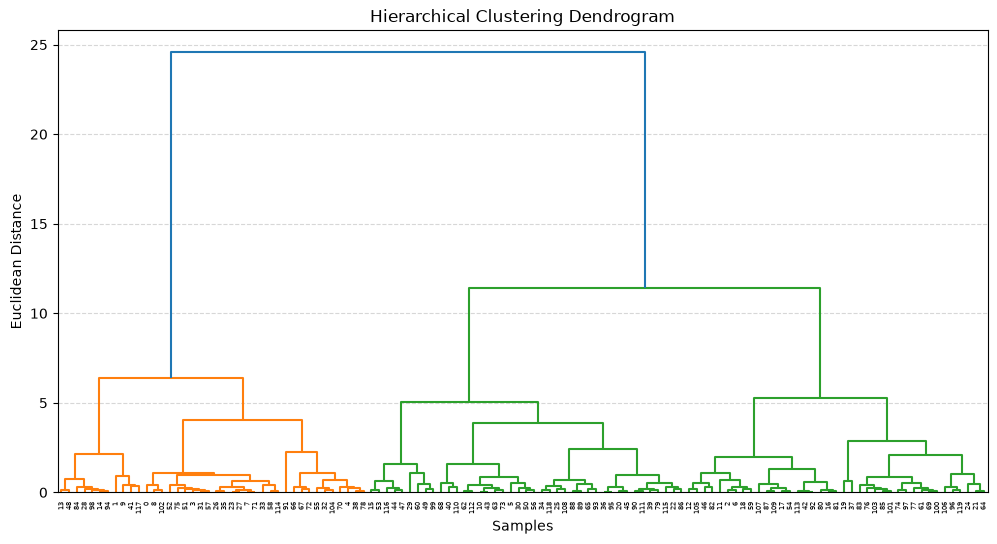

In [71]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Compute the linkage matrix
linked = linkage(X_train, method="ward")
# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    linked,
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

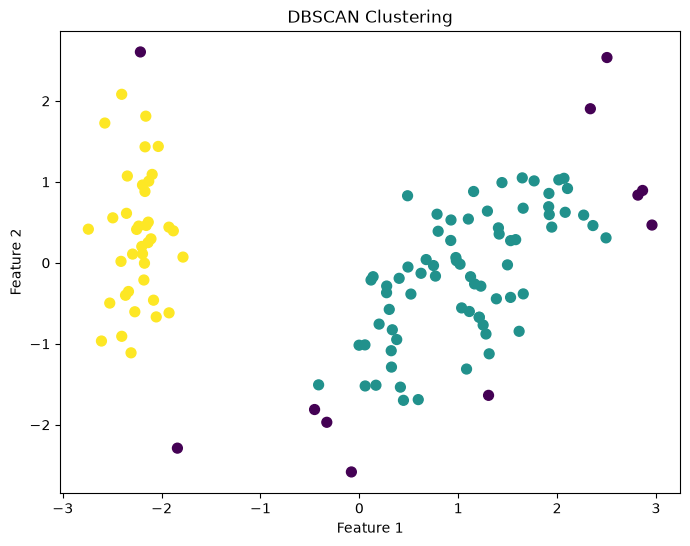

In [76]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

dbscan = DBSCAN(min_samples=5)

# Fit and predict
y_pred = dbscan.fit_predict(X_train)

# Plot clusters
plt.figure(figsize=(8,6))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_pred,
    cmap="viridis",
    s=50
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.show()

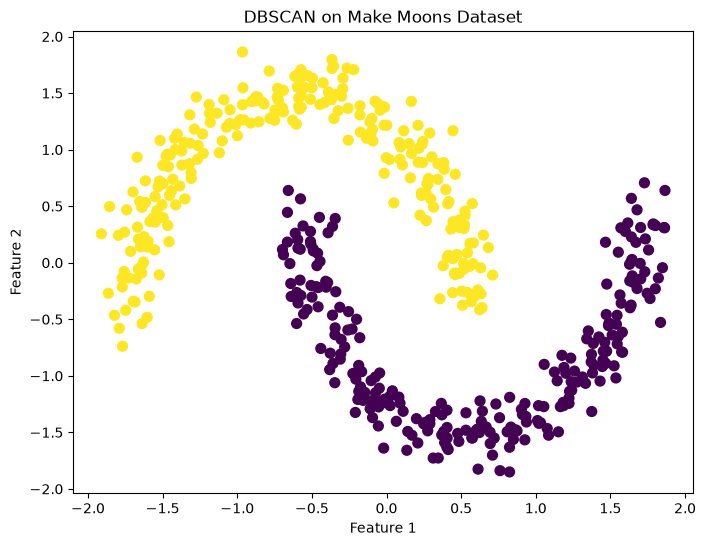

In [79]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Generate Make Moons dataset
X, y = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=42
)

# Standardize the data (recommended for DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(
    eps=0.25,
    min_samples=5
)

y_pred = dbscan.fit_predict(X_scaled)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y_pred,
    cmap="viridis",
    s=50
)

plt.title("DBSCAN on Make Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

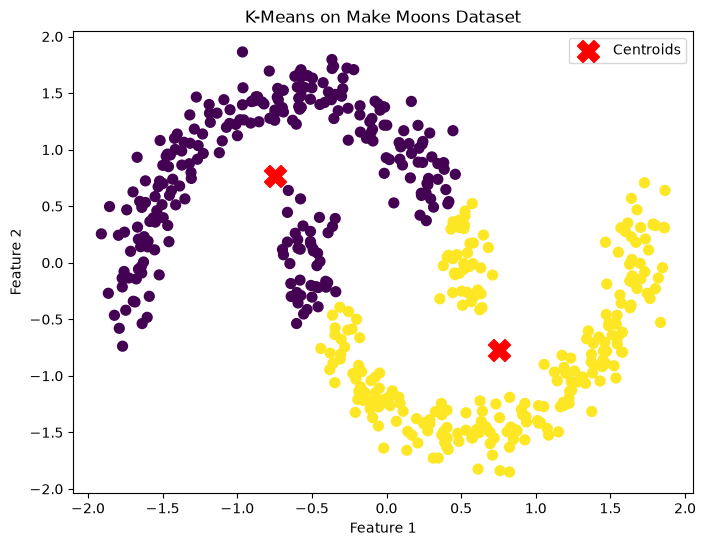

In [80]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply K-Means
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

y_pred = kmeans.fit_predict(X_scaled)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y_pred,
    cmap="viridis",
    s=50
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    color="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("K-Means on Make Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()